In [1]:
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

# **Lab 12 - Enabling inverse UQ with surrogate models**

Consider an inverse problem of the form
$$\mathbf{y}_i=Q(\mathbf{x}_i,u_{\boldsymbol{\mu}})+\boldsymbol{\varepsilon}_i$$
where:
- $\boldsymbol{\mu}\in\mathbb{R}^p$ is a vector of parameters, describing a physical system
- $u_{\boldsymbol{\mu}}$ is the solution to a parametrized PDE
- $Q(\mathbf{x},u)$ denotes a quantity of interest, computed at a given point in space (easily generalizable to a time-dependent setting)
- $i=1,\dots,n$ denote the different measurements
- $\boldsymbol{\varepsilon}_i\sim\mathcal{N}(0,\sigma^2\mathbf{I}_q)$ are $iid$ gaussian noises


Notice that, if we write $f(\mathbf{x},\boldsymbol{\mu}):=Q(\mathbf{x},u_{\boldsymbol{\mu}})$, then we end up in the usual framework. The only difficulty here is that every evaluation of $f$ requires computing $u_{\boldsymbol{\mu}}$, i.e. solving a differential problem. This can raise computational costs significantly, making the use of iterative algorithms (optimization for MLE, or MCMC for Bayesian approaches) prohibitive.

One approach is to replace $u_{\boldsymbol{\mu}}$ with a surrogate $\tilde{u}_{\boldsymbol{\mu}}$ that is cheaper to compute.

## **Example**: leakage detection

The code below gives access to a dataset of finite element simulations modeling water leakage in a cylindrical container. The model parameters
$$\boldsymbol{\mu}=[\theta,\rho_1,\rho_2]^\top,$$
describe the angle between the two holes in the walls, $\theta$, and the amplitude of the two holes, $\rho_1$, $\rho_2$. The phenomenon is modeled using the steady Navier-Stokes equations and the pressure field is returned as a solution $u_{\boldsymbol{\mu}}$.


The dataset consists of several independent simulations $\{\boldsymbol{\mu}_i,u_{\boldsymbol{\mu}_i}\}_{i=1}^N$.

Aside from this data, we are also given noisy measurements of the pressure field, obtained for an unknown value of the problem parameters $\boldsymbol{\mu_*}$:

$$y_i = u_{\boldsymbol{\mu_*}}(\mathbf{x}_i)$$

the measurements being taken by 7 equispaced sensors along the external wall. According to our previous notation, here $q=1$ and $Q(\mathbf{x},u):=u(\mathbf{x})$ is the evaluation functional.

In [2]:
import gdown
import numpy as np
from IPython.display import clear_output as clc

# Spatial discretization
gdown.download(id = "1PrQyfLv3Sjv8oOgZk48MR-miDAq0X4pO", output = "leak_mesh.xml")
mesh = fe.loadmesh("leak_mesh.xml")
Vh = fe.space(mesh, 'CG', 1)
clc()

In [3]:
# Dataset "parameters + pressure"
gdown.download(id = "1eEtqZPjLe3xPed15ckTAGNBYDQ8px8aJ", output = "leak_data.npz")
dataset = np.load("leak_data.npz")
mu, u = dataset['mu'], dataset['u']

# Pressure measurements (for inverse UQ)
gdown.download(id = "1STu-gV96oB4Gqtv-kf9aenXODqJ7kdIq", output = "sensor_measurements.npz")
measurements = np.load("sensor_measurements.npz")
sensors_location, sensors_values = measurements['sensor_indices'][:-1], measurements['pressure_measurements'][:-1]
clc()

In [4]:
mu.shape, u.shape

((200, 3), (200, 3899))

In [5]:
sensors_location.shape, sensors_values.shape

((7,), (7,))

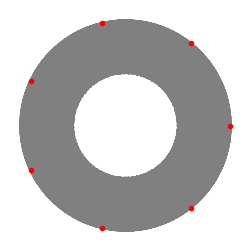

In [6]:
plt.figure(figsize = (3, 3))
fe.plot(mesh)
plt.plot(*fe.dofs(Vh)[sensors_location].T, '.r')
None

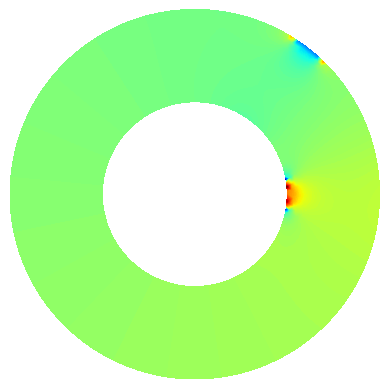

In [7]:
fe.plot(u[3], Vh)

In [8]:
mu[0]

array([1.89363699, 0.07744068, 0.08575947])

In [9]:
u[0][sensors_location]

array([0.82332861, 0.64023615, 0.50120456, 0.53532942, 0.59885631,
       0.66380033, 0.72833138])

<mark>**Exercise 1**</mark></br>
To start, find the simulation in the dataset that best fits the measurements.

In [10]:
def sensors_misfit(u):
  return np.sum((u[sensors_location] - sensors_values)**2)

misfits = np.array([sensors_misfit(uj) for uj in u])
jbest = misfits.argmin()

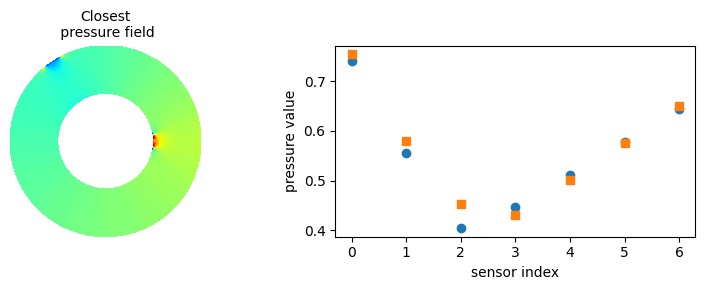

In [11]:
plt.figure(figsize = (8, 3))
plt.subplot(1, 2, 1)
fe.plot(u[jbest], Vh)
plt.title("Closest\n pressure field", fontsize = 10)
plt.subplot(1, 2, 2)
plt.plot(sensors_values, 'o')
plt.plot(u[jbest, sensors_location], 's')
plt.xlabel("sensor index")
plt.ylabel("pressure value")
plt.tight_layout()

<mark>**Exercise 2**</mark></br>
Use the data at hand to construct a surrogate model, to be used later on for inverse UQ.

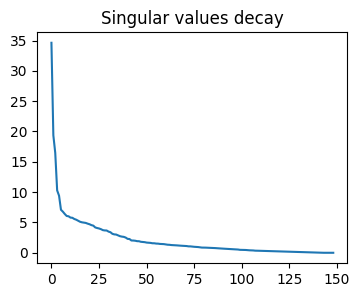

In [12]:
from scipy.linalg import svd
nh, p = u.shape[1], mu.shape[1]

ntrain = 150
X, s, Yh = svd(u[:ntrain].T, full_matrices = False)

plt.figure(figsize = (4, 3))
plt.plot(s[1:])
plt.title("Singular values decay")
None

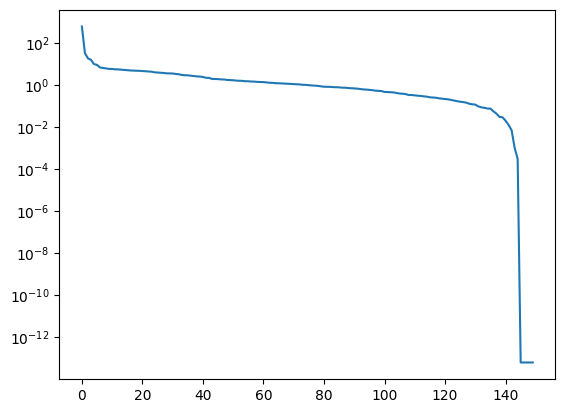

In [13]:
plt.semilogy(s)

In [14]:
n = 30
V = X[:, :n]

In [15]:
uproj = u @ V @ V.T
l2 = L2(Vh)
l2.to(dv)
clc()

In [16]:
mu, u, uproj, V = dv.tensor(mu, u, uproj, V)

In [17]:
# We can do this with library utility functions
num2p(mre(l2)(u[ntrain:], uproj[ntrain:]))

'1.80%'

In [18]:
# N_data x n
c = u @ V
c.shape

p = mu.shape[-1]
n = c.shape[-1]

architecture = Dense(p, 250, gelu) + Dense(250, 250, gelu) + Dense(250, n, None)
phi = DFNN(architecture)

phi.to(dv)
phi.He()
phi.train(mu, c, ntrain = ntrain, nvalid = 50, epochs = 50, loss = mse(euclidean))

phi.freeze()

		Train		Valid		Test
Epoch 21:	3.76e+01	9.51e+01	5.95e+01.

>> ETA: 13.25s.


Training complete. Elapsed time: 9.27 seconds.


In [19]:
# We can look at the solution to understand what this means
# Of course, we need to pass to the correct space:
# From R^n to the functional space

# Moreover, note that we here we took 500 solutions to 500
# different configurations
# Since this is fast, we can use this to simulate MC
upodnn = lambda mu: phi(mu) @ V.T
num2p(mre(l2)(u[ntrain:], upodnn(mu)[ntrain:]))

'12.10%'

Check solution for ways of saving weights online.

TypeError: 'function' object is not subscriptable

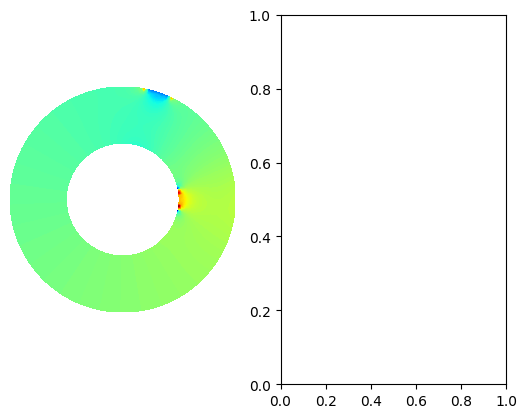

In [20]:
plt.subplot(1, 2, 1)
fe.plot(u[-1], Vh)
plt.subplot(1, 2, 2)
fe.plot(upodnn[-1], Vh)

<mark>**Exercise 3**</mark></br>
Leveraging the surrogate model, estimate the problem parameters using maximum likelihood estimation.

Be sure to include a quantification of the uncertainties as well.

**Can you locate where the hole is?**

In [ ]:
# Find "mu_MLE_tilde" via MLE with the ROM

def RSS(mu):
  # We need conversions because we are employing
  # both torch and numpy
  mu_tensor = dv.tensor(mu)
  u_predicted = upodnn(mu_tensor).cpu().numpy()
  return sensors_misfit(u_predicted)

A good starting point is for sure the best-fitting simulation.

In [ ]:
from scipy.optimize import minimize
result = minimize(RSS, x0 = mu[jbest].cpu().numpy(), method = "Powell")
mu_MLE_tilde = result.x
mu_MLE_tilde

In [ ]:
# Estimate residual variance "sigma2" and parameters standard errors "stds"
p = 3
q = 1
n = 7 # number of measurements, i.e. sensors
sigma2 = RSS(mu_MLE_tilde)/(n*q - p)

In [ ]:
from torch.autograd.functional import jacobian
measurements_map = lambda mu: upodnn(mu)[sensors_location]
J = jacobian(measurements_map, dv.tensor(mu_MLE_tilde)).cpu().numpy()
cov = sigma2 * np.linalg.inv(J.T @ J)
cov

In [ ]:
stds = np.diag(cov) ** 0.5
stds

In [ ]:
theta_minus = mu_MLE_tilde[0] - 2*stds[0]
theta_plus  = mu_MLE_tilde[0] + 2*stds[0]

In [ ]:
th = np.linspace(theta_minus, theta_plus, 100)
plt.figure(figsize = (3, 3))
fe.plot(mesh)
plt.fill([0, *np.cos(th)], [0, *np.sin(th)], 'r', alpha = 0.25)
plt.title("Confidence region", fontsize = 10)
None

<mark>**Exercise 4**</mark></br>
Leveraging the surrogate model, estimate the problem parameters using Bayesian inversion.

**Can you locate where the hole is?**

In [ ]:
def metropolis(nsim, mu0, prior, proposal_sampler, RSS, sigma2):
    chain = np.zeros((nsim, len(mu0)))
    chain[0, :] = mu0
    rej = 0
    rss = RSS(mu0)

    for i in range(nsim-1):
        current = chain[i, :]
        candidate = proposal_sampler(current)
        rss_new = RSS(candidate)

        # Metropolis acceptance ratio
        ratio = np.exp(-0.5 * (rss_new - rss) / sigma2)*prior(candidate)/prior(current)
        if np.random.rand() < ratio:  # Accept proposal
            chain[i+1, :] = candidate
            rss = rss_new
        else:  # Reject proposal
            chain[i+1, :] = current
            rej += 1

    accept_rate = 1 - rej / nsim
    return chain, accept_rate

In [ ]:
# Run Metropolis MCMC using the ROM
# These numbers are problem-given
improper_prior = lambda x: (np.abs(x[0] - np.pi/2) < np.pi/2)*(np.abs(x[1] - 0.075) < 0.025) + 0.0
# We can move very slowly, as model evaluations are cheap
proposal_sampler = lambda x: np.random.multivariate_normal(mean = x, cov = np.diag([1e-4, 1e-6, 1e-6]))

chain, acceptance_rate = metropolis(10000, mu_MLE_tilde, improper_prior, proposal_sampler, RSS, sigma2)

In [ ]:
plt.figure(figsize = (12, 3))
for i in range(p):
  plt.subplot(1, p, i+1)
  plt.plot(chain[:, i])

In [ ]:
# Analyze the chain and extract a posterior sample
b = 10000
lag = 500
[np.corrcoef(chain[b:-lag, i], chain[b+lag:, i])[0, 1] for i in range(p)]

In [ ]:
# Use the samples from the posterior to estimate a credibility interval for theta, [theta_minus_bayes, theta_plus_bayes]
poster_samples = chain[b::lag]
posterior_samples.shape

theta_posterior = posterior_samples[:, 0]

In [ ]:
theta_minus_bayes = np.quantile(theta_posterior, 0.025)
theta_plus_bayes = np.quantile(theta_posterior, 0.975)

In [ ]:
th_bayes = np.linspace(theta_minus_bayes, theta_plus_bayes, 100)
plt.figure(figsize = (3, 3))
fe.plot(mesh)
plt.fill([0, *np.cos(th_bayes)], [0, *np.sin(th_bayes)], 'b', alpha = 0.25)
plt.title("Credibility region", fontsize = 10)
None

In [ ]:
plt.figure(figsize = (3, 3))
fe.plot(mesh)
plt.fill([0, *np.cos(th)], [0, *np.sin(th)], 'r', alpha = 0.25, label = 'MLE')
plt.fill([0, *np.cos(th_bayes)], [0, *np.sin(th_bayes)], 'b', alpha = 0.25, label = 'Bayes')
plt.title("Regions vs true", fontsize = 10)
plt.legend(loc = "upper right")
None

Some alternative approaches:
 - delayed MC: run Navier-Stokes on accept